In [ ]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

segments = {
    "Segment_A": {"true_mu": 35, "true_sigma": 4, "n": 50},  # Lots of data
    "Segment_B": {"true_mu": 28, "true_sigma": 3, "n": 30},  # Moderate data
    "Segment_C": {"true_mu": 40, "true_sigma": 5, "n": 2},   # ALMOST NO DATA

}
# we cannot be training diff model for diff sections, since one has sparsy data

data_all = []
group_idx = []
group_names = []
for i, (name, params) in enumerate(segments.items()):
    samples = np.random.normal(params["true_mu"], params["true_sigma"], params["n"])
    data_all.extend(samples)
    group_idx.extend([i] * params["n"])
    # multing the list repeats it, so first is 50 0s
    group_names.append(name)
    print(f"{name}: n={params['n']}, true_mu={params['true_mu']}, sample_mean={samples.mean():.1f}")

data_all = np.array(data_all)
group_idx = np.array(group_idx)
n_groups = len(segments)


In [ ]:
# build TWO broken models (completely unpooled, completely pooled) to see their failures.

with pm.Model() as unpooled_model:
    #each segment has its own independent mu and sigma
    mu = pm.Normal("mu", mu=30, sigma=10, shape=n_groups)
    # shape imp here, every iteration its making 3 diff mus, instead of 1 as other times
    sigma = pm.HalfNormal("sigma", sigma=10, shape=n_groups)
    y = pm.Normal("y", mu=mu[group_idx], sigma=sigma[group_idx], observed=data_all)
    # `[group_idx]` wiring a list of variables to a list of data.


    trace_unpooled = pm.sample(draws=2000, tune=1000, cores=1, random_seed=42)

unpooled_means = trace_unpooled.posterior["mu"].values.reshape(-1, n_groups)
for i, name in enumerate(group_names):
    est = unpooled_means[:, i]
    print(f"{name}: estimated mu = {est.mean():.1f} ± {est.std():.1f} (TRUE: {list(segments.values())[i]['true_mu']})")


    # seg3 has so much std cuz very few observed

In [ ]:
with pm.Model() as pooled_model:
    # ONE mu for ALL segmentsd
    mu = pm.Normal("mu", mu=30, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=data_all)
    trace_pooled = pm.sample(draws=2000, tune=1000, cores=1, random_seed=42)

pooled_mu = trace_pooled.posterior["mu"].values.flatten().mean()
print(f"\nPooled estimate (ALL segments): mu = {pooled_mu:.1f}")

# pooling ignores real diff


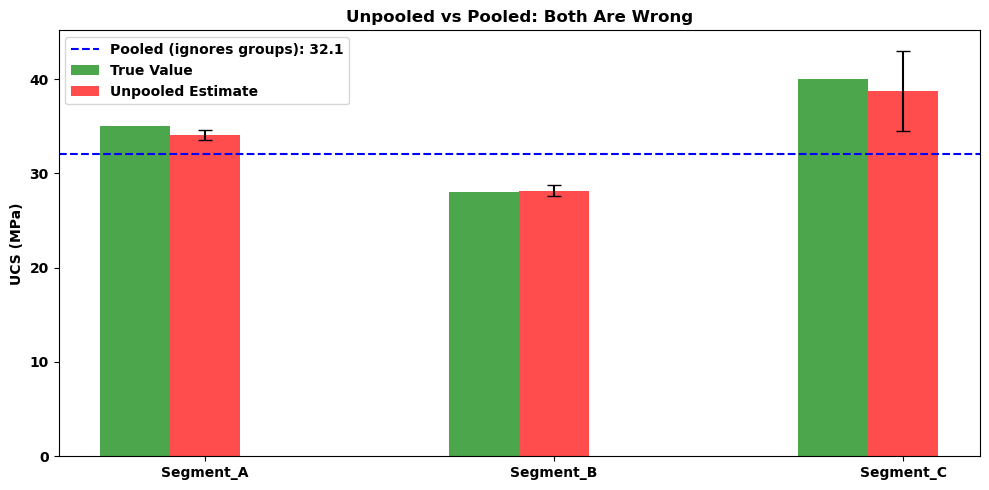

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
true_mus = [s["true_mu"] for s in segments.values()]
unpooled_ests = [unpooled_means[:, i].mean() for i in range(n_groups)]
unpooled_stds = [unpooled_means[:, i].std() for i in range(n_groups)]

x_pos = np.arange(n_groups)
ax.bar(x_pos - 0.2, true_mus, 0.2, label='True Value', color='green', alpha=0.7)
ax.bar(x_pos, unpooled_ests, 0.2, label='Unpooled Estimate', color='red', alpha=0.7,
       yerr=unpooled_stds, capsize=5)
ax.axhline(pooled_mu, color='blue', linestyle='--', label=f'Pooled (ignores groups): {pooled_mu:.1f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(group_names)
ax.set_ylabel("UCS (MPa)")
ax.set_title("Unpooled vs Pooled: Both Are Wrong")
ax.legend()
plt.tight_layout()
plt.show()


# With infinite (enough) data, Bayesian Inference and
# standard Frequentist averages become the exact same thing

# next our goal is to tell the engine that tho diff segments, they are part of the same 'main' mountain